# Investigating the multi-task ChromBPNet nucleosome model

This notebook walks through **exactly what the trained model sees and produces**, end to end:

1. **Load** a trained checkpoint
2. **Example input** — pick a genomic region and examine the raw DNA
3. **Tokenization** — DNA → one-hot, *the actual tensor fed to the CNN*
4. **Output** — run the forward pass and interpret the four output heads
5. **Inference** — reusable helpers to predict from a region or a raw sequence

**Architecture (recap).** A shared trunk — one `Conv1d(4→512, k=21)` then 8 dilated
residual `Conv1d(512→512, k=3, dilation=2..256)` layers — feeds **two BPNet-style heads**:
an *accessibility cut-site* head and a *nucleosome dyad* head. Each head emits a
**profile** (per-base shape, a length-`outputlen` logit vector) and a scalar **log-count**.
The `inputlen=2114 → outputlen=1000` crop falls out of the valid-padding conv stack.

> Paths below point at the H100 box (`~/atac/...`). Edit the CONFIG cell to repoint.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import pyfaidx, pyBigWig

from chrombpnet.training.utils.one_hot import dna_to_one_hot, one_hot_to_dna
from chrombpnet.training.models.multitask_nucleosome_torch import MultiTaskNucleosomeModel
from chrombpnet.multitask.torch_data import _fetch_seq, _fetch_bw

torch.manual_seed(0); np.random.seed(0)
print("torch", torch.__version__)


torch 2.12.0.dev20260407+cu128


## CONFIG — inputs

In [2]:
CKPT   = os.path.expanduser("~/atac/run_multitask/model_fold0.pt")   # or .../model.pt
GENOME = os.path.expanduser("~/atac/data/hg38.fa")
ACC_BW = os.path.expanduser("~/atac/data/GM12878.accessibility_cutsite.bw")
NUC_BW = os.path.expanduser("~/atac/data/GM12878.nucleosome_dyad.bw")
PEAKS  = os.path.expanduser("~/atac/peaks/peaks.narrowPeak")
for p in [CKPT, GENOME, ACC_BW, NUC_BW, PEAKS]:
    assert os.path.exists(p), f"missing: {p}"
print("all inputs present")


all inputs present


## 1. Load the trained model

The checkpoint stores `model_state_dict`, the full `args` used to train, and the best
`val_loss`. We rebuild the architecture from the saved hyperparameters so the shapes
match exactly, then load the weights.

In [3]:
ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)
a = ckpt["args"]
print("checkpoint hyperparameters:")
for k in ["inputlen","outputlen","filters","n_dil_layers","batch_size","epochs","learning_rate"]:
    print(f"  {k:14s} = {a[k]}")
print("stored best val_loss:", ckpt["val_loss"])

model = MultiTaskNucleosomeModel(a["inputlen"], a["outputlen"], a["filters"], a["n_dil_layers"])
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

INPUTLEN, OUTPUTLEN = a["inputlen"], a["outputlen"]
nparams = sum(p.numel() for p in model.parameters())
print(f"\nloaded model: {nparams:,} parameters | inputlen={INPUTLEN} outputlen={OUTPUTLEN}")


checkpoint hyperparameters:
  inputlen       = 2114
  outputlen      = 1000
  filters        = 512
  n_dil_layers   = 8
  batch_size     = 64
  epochs         = 50
  learning_rate  = 0.001
stored best val_loss: 1368.0725472368906

loaded model: 6,416,900 parameters | inputlen=2114 outputlen=1000


## 2. Example input — pick a region

Training centers each window on a peak **summit** (`center = start + summit_offset`).
We pick the strongest peak on chr1 for a clean, high-signal example.

In [4]:
peaks = pd.read_csv(PEAKS, sep="\t", header=None,
    names=["chr","start","end","name","score","strand","signal","pval","qval","summit"])
peaks = peaks[peaks["chr"]=="chr1"].sort_values("score", ascending=False).reset_index(drop=True)
row = peaks.iloc[0]
chrom  = row["chr"]
center = int(row["start"] + row["summit"])
print(f"example peak : {chrom}:{row['start']}-{row['end']}  summit_off={row['summit']}  MACS_score={row['score']}")
print(f"window center: start+summit = {center}")
print(f"model input  : [{center-INPUTLEN//2}, {center+INPUTLEN//2})  ->  {INPUTLEN} bp of DNA")


example peak : chr1:171781072-171781730  summit_off=413  MACS_score=32559
window center: start+summit = 171781485
model input  : [171780428, 171782542)  ->  2114 bp of DNA


## 3. Tokenization — DNA → one-hot (the actual CNN input)

The "tokenizer" is `dna_to_one_hot`: each base becomes a length-4 one-hot vector in
**A, C, G, T** column order. Anything that isn't A/C/G/T (e.g. `N`) becomes **all zeros**.
The result is an `inputlen × 4` array.

In [5]:
genome = pyfaidx.Fasta(GENOME)
s = center - INPUTLEN//2
e = center + INPUTLEN//2
seq = str(genome[chrom][s:e]).upper()
print("sequence length:", len(seq))
print("first 60 bp    :", seq[:60])

onehot = dna_to_one_hot([seq])[0].astype(np.float32)
print("one-hot shape  :", onehot.shape, "| dtype:", onehot.dtype)   # (inputlen, 4)


sequence length: 2114
first 60 bp    : TTAACTATTAACAGTCTACCTGGCTATCTACCTGTGGTAGTGTAGTATGTAACAGCCCAC
one-hot shape  : (2114, 4) | dtype: float32


In [6]:
# Letter <-> one-hot row, first 12 bases. Columns are A, C, G, T.
demo = pd.DataFrame(onehot[:12].astype(int), columns=list("ACGT"))
demo.insert(0, "base", list(seq[:12]))
print(demo.to_string(index=False))

comp = onehot.sum(axis=0).astype(int)
n_zero = int((onehot.sum(axis=1) == 0).sum())
print(f"\nbase counts  A,C,G,T = {comp}   (sum={comp.sum()})")
print(f"all-zero (N/other) positions = {n_zero}")


base  A  C  G  T
   T  0  0  0  1
   T  0  0  0  1
   A  1  0  0  0
   A  1  0  0  0
   C  0  1  0  0
   T  0  0  0  1
   A  1  0  0  0
   T  0  0  0  1
   T  0  0  0  1
   A  1  0  0  0
   A  1  0  0  0
   C  0  1  0  0

base counts  A,C,G,T = [531 511 603 469]   (sum=2114)
all-zero (N/other) positions = 0


### How it enters the CNN

The dataset yields one example as `(L, 4)`. We add a batch dimension → `(1, L, 4)`.
The model's `forward` checks `if seq.shape[1] != 4: seq = seq.transpose(1, 2)`, so it
**transposes to `(B, 4, L)`** — the channels-first layout `Conv1d` expects (4 input
channels = the 4 bases).

In [7]:
x = torch.from_numpy(onehot).unsqueeze(0)          # (1, L, 4)
print("tensor passed to model():", tuple(x.shape), x.dtype)
print("model transposes it to   :", (1, 4, INPUTLEN), "-> Conv1d(in_channels=4)")


tensor passed to model(): (1, 2114, 4) torch.float32
model transposes it to   : (1, 4, 2114) -> Conv1d(in_channels=4)


## 4. Output — forward pass

One call returns **four** tensors: `(acc_profile, acc_count, nuc_profile, nuc_count)`.
Profiles are length-`outputlen` **logits**; counts are scalar **log1p(total)** values.

In [8]:
with torch.no_grad():
    acc_profile, acc_count, nuc_profile, nuc_count = model(x)

print("acc_profile (logits) :", tuple(acc_profile.shape))
print("acc_count   (log1p)  :", tuple(acc_count.shape), "=", round(float(acc_count), 4))
print("nuc_profile (logits) :", tuple(nuc_profile.shape))
print("nuc_count   (log1p)  :", tuple(nuc_count.shape), "=", round(float(nuc_count), 4))


acc_profile (logits) : (1, 1000)
acc_count   (log1p)  : (1, 1) = 8.7674
nuc_profile (logits) : (1, 1000)
nuc_count   (log1p)  : (1, 1) = 6.6904


## 5. Interpreting the outputs

The profile is trained with a **multinomial** loss, so `softmax(profile)` is a probability
distribution over the `outputlen` positions — the *shape* of the signal. The count head
predicts `log1p(total signal)`, so `expm1(log_count)` recovers the **total**. Multiplying
gives the expected **per-base signal**:

```
per_base_signal = softmax(profile) * expm1(log_count)
```

In [9]:
def decode(profile_logits, logcount):
    prob  = torch.softmax(profile_logits, dim=-1).squeeze(0).numpy()  # sums to 1
    total = float(torch.expm1(logcount))                             # undo log1p
    return prob, total, prob * total

acc_prob, acc_total, acc_pred = decode(acc_profile, acc_count)
nuc_prob, nuc_total, nuc_pred = decode(nuc_profile, nuc_count)
print(f"predicted total accessibility counts : {acc_total:8.1f}")
print(f"predicted total nucleosome counts    : {nuc_total:8.1f}")
print(f"profile prob sums (sanity, ~1.0)     : acc={acc_prob.sum():.4f}  nuc={nuc_prob.sum():.4f}")


predicted total accessibility counts :   6420.5
predicted total nucleosome counts    :    803.7
profile prob sums (sanity, ~1.0)     : acc=1.0000  nuc=1.0000


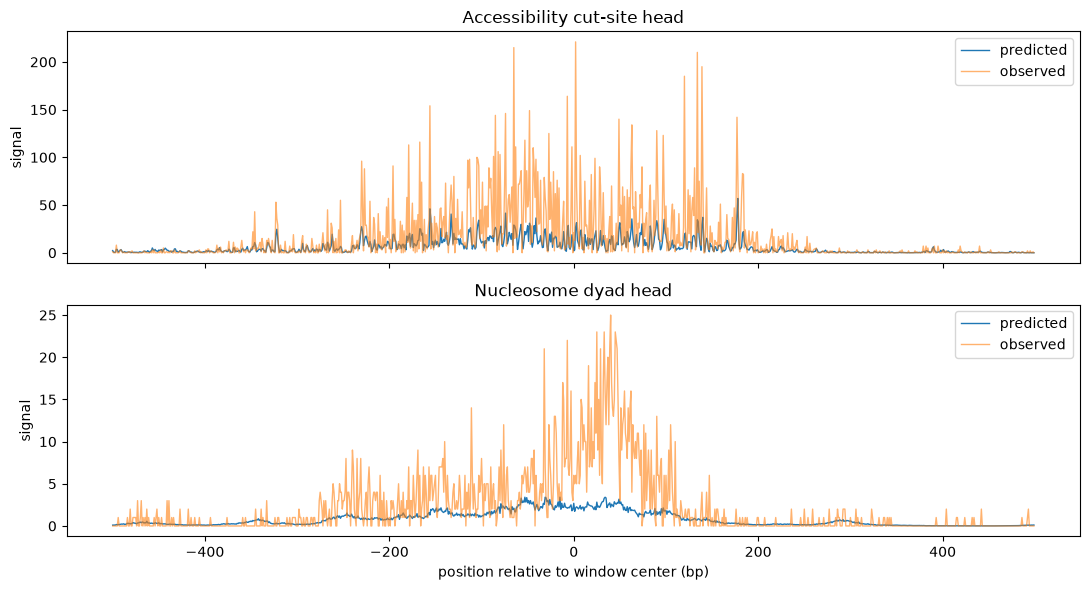

In [10]:
# Compare predicted vs observed signal in the central outputlen window.
acc_obs = _fetch_bw(pyBigWig.open(ACC_BW), chrom, center, OUTPUTLEN)
nuc_obs = _fetch_bw(pyBigWig.open(NUC_BW), chrom, center, OUTPUTLEN)
xx = np.arange(OUTPUTLEN) - OUTPUTLEN // 2

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(xx, acc_pred, lw=1, label="predicted")
ax[0].plot(xx, acc_obs,  lw=1, alpha=.6, label="observed")
ax[0].set_title("Accessibility cut-site head"); ax[0].set_ylabel("signal"); ax[0].legend()
ax[1].plot(xx, nuc_pred, lw=1, label="predicted")
ax[1].plot(xx, nuc_obs,  lw=1, alpha=.6, label="observed")
ax[1].set_title("Nucleosome dyad head"); ax[1].set_ylabel("signal")
ax[1].set_xlabel("position relative to window center (bp)"); ax[1].legend()
plt.tight_layout(); plt.show()


## 6. Inference helpers

`predict_region` uses the dataset's canonical `_fetch_seq` (returns the `(L,4)` one-hot
directly). `predict_from_seq` takes a raw `inputlen`-bp string. Both return decoded
probability / total / per-base arrays for each head.

In [11]:
def predict_region(chrom, center):
    seq = _fetch_seq(genome, chrom, center, INPUTLEN)     # (L, 4) one-hot, canonical path
    x = torch.from_numpy(seq).unsqueeze(0)
    with torch.no_grad():
        ap, ac, npf, nc = model(x)
    return {"acc": decode(ap, ac), "nuc": decode(npf, nc)}

def predict_from_seq(seq_str):
    assert len(seq_str) == INPUTLEN, f"need {INPUTLEN} bp, got {len(seq_str)}"
    oh = dna_to_one_hot([seq_str.upper()])[0].astype(np.float32)
    x = torch.from_numpy(oh).unsqueeze(0)
    with torch.no_grad():
        ap, ac, npf, nc = model(x)
    return {"acc": decode(ap, ac), "nuc": decode(npf, nc)}

out = predict_region(chrom, center)
print("predict_region ->")
for head in ("acc", "nuc"):
    prob, total, per_base = out[head]
    print(f"  {head}: prob{prob.shape} sum={prob.sum():.3f}  total={total:.1f}  per_base{per_base.shape}")


predict_region ->
  acc: prob(1000,) sum=1.000  total=6420.5  per_base(1000,)
  nuc: prob(1000,) sum=1.000  total=803.7  per_base(1000,)


## Summary — shapes & dimensions

| Stage | Object | Shape | Meaning |
|---|---|---|---|
| DNA | `seq` | `(2114,)` str | reference window centered on summit |
| Tokenize | `onehot` | `(2114, 4)` | A,C,G,T one-hot; N → all-zeros |
| CNN input | `x` | `(1, 2114, 4)` → `(1, 4, 2114)` | model transposes to channels-first |
| Trunk | hidden | `(1, 512, 1074)` | after k=21 conv + 8 dilated residual layers |
| Output | `acc_profile`, `nuc_profile` | `(1, 1000)` | per-base **logits** (softmax → shape) |
| Output | `acc_count`, `nuc_count` | `(1, 1)` | **log1p(total)** signal |

**Decode:** `per_base = softmax(profile) * expm1(log_count)`. Profile uses a multinomial
NLL (shape), count uses MSE on `log1p` (depth). Two heads share the trunk: accessibility
cut-site + nucleosome dyad.